# TP 4 — Prototype de priorisation des événements de sécurité

**Équipe :** _(vos noms)_

Ce notebook est un point de départ. Il ne contient **aucune solution** : à vous de le remplir.

Rappel de la mission : concevoir et évaluer un prototype de classification répartissant les événements entre `NORMAL`, `SUSPICIOUS` et `MALICIOUS`.

> Votre objectif n'est pas uniquement d'obtenir le meilleur score statistique. Vous devez proposer un modèle cohérent avec les conséquences opérationnelles des faux positifs et des faux négatifs.

## 0. Imports

In [39]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

import matplotlib.pyplot as plt

RANDOM_STATE = 42  # à conserver pour que vos résultats soient reproductibles

## 1. Chargement des données

In [40]:
df = pd.read_csv("../data/tp4/cleaned_dataset.csv")
df.head()

,timestamp,source,event_id,user_id,device_id,src_ip,src_ip_valid,event_type,process_name,severity,...,employment_status,privileged_account,hostname,asset_type,asset_owner,asset_criticality,user_known,device_known,label,triage_label
0,2026-03-02 01:31:00,authentication_logs,AUTH003692,U0190,D0154,10.27.255.130,True,MFA_CHALLENGE,UNKNOWN,MEDIUM,...,ACTIVE,YES,PHF-LT-0154,Mobile,Finance,HIGH,True,True,UNLABELED,SUSPICIOUS
1,2026-03-02 01:41:00,authentication_logs,AUTH000733,U0008,D0029,10.21.247.242,True,LOGOUT,UNKNOWN,LOW,...,ACTIVE,NO,PHF-WS-0029,Server,IT,CRITICAL,True,True,UNLABELED,MALICIOUS
2,2026-03-02 01:53:00,authentication_logs,AUTH000859,U0343,D0025,10.12.238.24,True,LOGIN,UNKNOWN,MEDIUM,...,ACTIVE,NO,PHF-WS-0025,Laptop,RH,LOW,True,True,UNLABELED,NORMAL
3,2026-03-02 02:32:15,authentication_logs,AUTH002474,U0202,D0053,10.42.152.134,True,PASSWORD_CHANGE,UNKNOWN,MEDIUM,...,ACTIVE,NO,PHF-SRV-0053,Server,Regions,MEDIUM,True,True,UNLABELED,SUSPICIOUS
4,2026-03-02 02:50:24,authentication_logs,AUTH002027,U0226,D0041,10.39.189.42,True,MFA_CHALLENGE,UNKNOWN,LOW,...,ACTIVE,NO,PHF-SRV-0041,VM,Direction,CRITICAL,True,True,UNLABELED,SUSPICIOUS


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6702 entries, 0 to 6701
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   timestamp              6702 non-null   str  
 1   source                 6702 non-null   str  
 2   event_id               6702 non-null   str  
 3   user_id                6702 non-null   str  
 4   device_id              6702 non-null   str  
 5   src_ip                 6702 non-null   str  
 6   src_ip_valid           6702 non-null   bool 
 7   event_type             6702 non-null   str  
 8   process_name           6702 non-null   str  
 9   severity               6702 non-null   str  
 10  authentication_result  6702 non-null   str  
 11  location               6702 non-null   str  
 12  user_department        6702 non-null   str  
 13  user_role              6702 non-null   str  
 14  employment_status      6702 non-null   str  
 15  privileged_account     6702 non-null   str  
 16 

## 2. Analyse de la cible

À traiter :
- distribution des trois classes ;
- ampleur du déséquilibre ;
- conséquence sur le choix des métriques.

**Question :** si un modèle prédisait toujours la classe majoritaire, quelle accuracy obtiendrait-il ?

In [42]:
# Nombre d'événements par classe
distribution = df["triage_label"].value_counts()

print("Distribution des classes :")
print(distribution)

print("\nRépartition en pourcentage :")
print(
    (distribution / len(df) * 100)
    .round(2)
)

Distribution des classes :
triage_label
NORMAL        4948
SUSPICIOUS    1284
MALICIOUS      470
Name: count, dtype: int64

Répartition en pourcentage :
triage_label
NORMAL        73.83
SUSPICIOUS    19.16
MALICIOUS      7.01
Name: count, dtype: float64


### Analyse

La classe `NORMAL` est largement majoritaire avec environ 73,8 % des événements.
La classe `MALICIOUS` ne représente qu'environ 7 % du dataset.

Le dataset est donc déséquilibré. L'accuracy seule ne sera pas suffisante pour
évaluer correctement les modèles, car elle peut masquer de mauvaises performances
sur les classes minoritaires.

Il faudra notamment étudier le recall et le F1-score de chaque classe,
en particulier pour `MALICIOUS`.

## 3. Colonnes utilisables et fuite de cible

Passez en revue **chaque colonne** et décidez si elle peut servir de variable d'entrée.

Pour chacune, posez-vous la question : *cette information est-elle disponible au moment où le système doit prioriser un événement qui vient d'arriver ?*

Documentez vos exclusions et leur motif — c'est un livrable attendu.

In [43]:
# TODO : lister les colonnes, décider lesquelles exclure et pourquoi

# Liste des colonnes du dataset
print(df.columns.tolist())

# Colonnes à exclure du modèle
excluded_columns = [
    "triage_label",  # cible à prédire
    "label",         # décision analyste disponible après investigation
    "event_id"       # identifiant unique, pas une information métier utile
]

print("\nColonnes exclues :")
for col in excluded_columns:
    print("-", col)

print("\nLien entre label analyste et triage_label :")

print(
    pd.crosstab(
        df["label"],
        df["triage_label"],
        normalize="index"
    ).round(3)
)

['timestamp', 'source', 'event_id', 'user_id', 'device_id', 'src_ip', 'src_ip_valid', 'event_type', 'process_name', 'severity', 'authentication_result', 'location', 'user_department', 'user_role', 'employment_status', 'privileged_account', 'hostname', 'asset_type', 'asset_owner', 'asset_criticality', 'user_known', 'device_known', 'label', 'triage_label']

Colonnes exclues :
- triage_label
- label
- event_id

Lien entre label analyste et triage_label :
triage_label         MALICIOUS  NORMAL  SUSPICIOUS
label                                             
FALSE_POSITIVE           0.036   0.810       0.155
NEEDS_INVESTIGATION      0.789   0.025       0.186
TRUE_POSITIVE            1.000   0.000       0.000
UNLABELED                0.045   0.751       0.204


### Fuite de cible

La colonne `label` ne doit pas être utilisée comme variable d'entrée.

Elle correspond à la décision prise par l'analyste après le traitement de
l'événement. Or le modèle doit prioriser l'événement avant cette investigation.

L'utilisation de cette colonne constituerait donc une fuite de cible :
le modèle disposerait indirectement d'une information sur la réponse qu'il
cherche à prédire.

Le lien est particulièrement fort puisque les événements `TRUE_POSITIVE`
sont tous associés à la classe `MALICIOUS`.

`triage_label` est également exclue des variables d'entrée puisqu'il s'agit
de la cible à prédire. `event_id` est exclu car il s'agit uniquement d'un
identifiant unique sans valeur prédictive métier.

## 4. Feature engineering

Certains signaux utiles ne sont pas dans le fichier et doivent être construits.

Pistes (ni obligatoires ni exhaustives) : heure de l'événement, activité nocturne, échecs d'authentification récents pour un même utilisateur, succès après une série d'échecs, volume d'activité par utilisateur ou machine, localisation inhabituelle, croisement privilèges × criticité de l'actif.

Justifiez les variables que vous retenez.

In [44]:
# TODO : construire vos features

# Copie du dataset pour construire les variables du modèle
df_model = df.copy()

# Conversion du timestamp en vraie date
df_model["timestamp"] = pd.to_datetime(df_model["timestamp"])

# Informations temporelles
df_model["hour"] = df_model["timestamp"].dt.hour
df_model["day_of_week"] = df_model["timestamp"].dt.dayofweek

# Événement réalisé la nuit : entre 22h et 6h
df_model["is_night"] = (
    (df_model["hour"] >= 22)
    | (df_model["hour"] < 6)
).astype(int)

# Échec d'authentification
df_model["failed_auth"] = (
    df_model["authentication_result"] == "FAILED"
).astype(int)

# Combinaison compte privilégié + actif critique
df_model["privileged_critical"] = (
    (df_model["privileged_account"] == "YES")
    & (df_model["asset_criticality"] == "CRITICAL")
).astype(int)

print(
    df_model[
        [
            "timestamp",
            "hour",
            "day_of_week",
            "is_night",
            "failed_auth",
            "privileged_critical"
        ]
    ].head()
)

            timestamp  hour  day_of_week  is_night  failed_auth  \
0 2026-03-02 01:31:00     1            0         1            0   
1 2026-03-02 01:41:00     1            0         1            1   
2 2026-03-02 01:53:00     1            0         1            0   
3 2026-03-02 02:32:15     2            0         1            0   
4 2026-03-02 02:50:24     2            0         1            0   

   privileged_critical  
0                    0  
1                    0  
2                    0  
3                    0  
4                    0  


### Features retenues

Plusieurs variables simples ont été construites à partir des informations
disponibles au moment de l'événement :

- `hour` : heure de l'événement ;
- `day_of_week` : jour de la semaine ;
- `is_night` : indique si l'événement se produit entre 22h et 6h ;
- `failed_auth` : indique un échec d'authentification ;
- `privileged_critical` : combinaison entre un compte privilégié et un actif critique.

Ces variables ont été retenues car elles peuvent apporter du contexte au modèle
sans utiliser d'information issue de l'investigation humaine.

Les variables temporelles plus complexes comme le nombre d'échecs récents ou
la fréquence d'activité pourront être ajoutées ensuite, mais elles doivent être
calculées uniquement à partir des événements antérieurs afin d'éviter une fuite
d'information.

## 5. Séparation train / test

Pensez à la **stratification** : avec une classe minoritaire à ~7 %, un split non stratifié peut déséquilibrer fortement le jeu de test.

In [45]:
# TODO : train_test_split stratifié
# Cible à prédire
y = df_model["triage_label"]

# Variables d'entrée
X = df_model.drop(
    columns=[
        "triage_label",
        "label",
        "event_id",
        "timestamp",
        "user_id",
        "device_id",
        "src_ip",
        "hostname"
    ]
)

# Séparation train / test en conservant la proportion des classes
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Taille du train :", len(X_train))
print("Taille du test  :", len(X_test))

print("\nDistribution dans le train :")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nDistribution dans le test :")
print((y_test.value_counts(normalize=True) * 100).round(2))

Taille du train : 5361
Taille du test  : 1341

Distribution dans le train :
triage_label
NORMAL        73.83
SUSPICIOUS    19.16
MALICIOUS      7.01
Name: proportion, dtype: float64

Distribution dans le test :
triage_label
NORMAL        73.83
SUSPICIOUS    19.16
MALICIOUS      7.01
Name: proportion, dtype: float64


### Séparation des données

Le dataset est séparé en 80 % pour l'entraînement et 20 % pour le test.

La séparation est stratifiée sur `triage_label` afin de conserver une proportion
similaire de `NORMAL`, `SUSPICIOUS` et `MALICIOUS` dans les deux jeux.

Le jeu de test reste totalement séparé de l'entraînement et servira uniquement
à mesurer les performances finales des modèles.

## 6. Preprocessing

Les variables catégorielles doivent être encodées, les numériques mises à l'échelle pour certains modèles. Utilisez un `ColumnTransformer` dans un `Pipeline` : cela évite toute fuite entre train et test.

In [46]:
# TODO : ColumnTransformer + Pipeline
# Variables numériques
numeric_features = [
    "hour",
    "day_of_week",
    "is_night",
    "failed_auth",
    "privileged_critical",
    "src_ip_valid",
    "user_known",
    "device_known"
]

# Variables catégorielles
categorical_features = [
    "source",
    "event_type",
    "process_name",
    "severity",
    "authentication_result",
    "location",
    "user_department",
    "user_role",
    "employment_status",
    "privileged_account",
    "asset_type",
    "asset_owner",
    "asset_criticality"
]

# Préparation des données
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="drop"
)

print("Variables numériques :", len(numeric_features))
print("Variables catégorielles :", len(categorical_features))

Variables numériques : 8
Variables catégorielles : 13


### Prétraitement

Les variables ont été séparées entre variables numériques et catégorielles.

Les variables catégorielles sont transformées avec un `OneHotEncoder` afin
d'être utilisables par les modèles. L'option `handle_unknown="ignore"` permet
également de gérer une catégorie qui apparaîtrait uniquement dans le jeu de test.

Les variables numériques sont standardisées avec `StandardScaler`.

Les identifiants directs comme `user_id`, `device_id`, `src_ip` et `hostname`
ne sont pas utilisés comme variables d'entrée afin de limiter le risque que le
modèle mémorise des entités précises plutôt que des comportements généraux.

Le preprocessing sera intégré dans les pipelines des modèles afin qu'il soit
appris uniquement à partir du jeu d'entraînement.

## 7. Baseline **obligatoire**

Avant tout modèle, construisez une baseline naïve : par exemple prédire systématiquement la classe majoritaire (`DummyClassifier`).

C'est le point de comparaison sans lequel vos scores ne veulent rien dire.

In [47]:
# TODO : baseline
# Baseline : prédit toujours la classe majoritaire
baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_macro_f1 = f1_score(
    y_test,
    y_pred_baseline,
    average="macro"
)

print("Classe prédite par la baseline :", baseline.classes_[np.argmax(baseline.class_prior_)])

print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Macro F1 : {baseline_macro_f1:.4f}")

Classe prédite par la baseline : NORMAL
Accuracy : 0.7383
Macro F1 : 0.2831


### Analyse de la baseline

La baseline prédit systématiquement la classe majoritaire `NORMAL`.

Elle obtient environ **73,8 % d'accuracy**, ce qui peut sembler élevé, mais
cette performance est uniquement liée au déséquilibre du dataset.

Le modèle ne détecte aucun événement `SUSPICIOUS` ou `MALICIOUS`.
Son macro F1 est donc faible, autour de **0,28**.

Cette baseline servira de référence pour évaluer les véritables modèles.

## 8. Entraîner au moins deux modèles

Par exemple parmi : régression logistique, arbre de décision, forêt aléatoire.

Ne présumez pas qu'un modèle complexe sera meilleur : vérifiez-le.

In [48]:
# TODO : modèle 1
from sklearn.base import clone

# Pipeline : preprocessing + régression logistique
logistic_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# Entraînement
logistic_model.fit(X_train, y_train)

# Prédictions
y_pred_logistic = logistic_model.predict(X_test)

print("Régression logistique entraînée.")

Régression logistique entraînée.


In [49]:
# TODO : modèle 2
# Pipeline : preprocessing + arbre de décision
tree_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# Entraînement
tree_model.fit(X_train, y_train)

# Prédictions
y_pred_tree = tree_model.predict(X_test)

print("Arbre de décision entraîné.")

Arbre de décision entraîné.


In [50]:
# Pipeline : preprocessing + forêt aléatoire
forest_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Entraînement
forest_model.fit(X_train, y_train)

# Prédictions
y_pred_forest = forest_model.predict(X_test)

print("Forêt aléatoire entraînée.")

Forêt aléatoire entraînée.


## 9. Évaluation

Pour chaque modèle, produisez :
- la matrice de confusion (3×3) ;
- precision, recall et F1 **par classe** ;
- le macro F1 et le F1 pondéré ;
- le nombre de faux positifs et de faux négatifs.

Comparez systématiquement à la baseline.

In [51]:
# TODO : évaluation comparée
labels = ["NORMAL", "SUSPICIOUS", "MALICIOUS"]

models_predictions = {
    "Baseline": y_pred_baseline,
    "Régression logistique": y_pred_logistic,
    "Arbre de décision": y_pred_tree,
    "Random Forest": y_pred_forest
}

results = []

for model_name, predictions in models_predictions.items():

    accuracy = accuracy_score(y_test, predictions)

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    # Faux négatifs MALICIOUS :
    # événement réellement malveillant mais non détecté comme MALICIOUS
    false_negatives = (
        (y_test == "MALICIOUS")
        & (predictions != "MALICIOUS")
    ).sum()

    # Faux positifs MALICIOUS :
    # événement non malveillant prédit MALICIOUS
    false_positives = (
        (y_test != "MALICIOUS")
        & (predictions == "MALICIOUS")
    ).sum()

    # Recall de la classe MALICIOUS
    malicious_recall = recall_score(
        y_test,
        predictions,
        labels=["MALICIOUS"],
        average="macro",
        zero_division=0
    )

    results.append({
        "Modèle": model_name,
        "Accuracy": accuracy,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Recall MALICIOUS": malicious_recall,
        "FP MALICIOUS": false_positives,
        "FN MALICIOUS": false_negatives
    })


results_df = pd.DataFrame(results)

print(
    results_df
    .round(3)
    .to_string(index=False)
)


               Modèle  Accuracy  Macro F1  Weighted F1  Recall MALICIOUS  FP MALICIOUS  FN MALICIOUS
             Baseline     0.738     0.283        0.627             0.000             0            94
Régression logistique     0.748     0.692        0.771             0.766            42            22
    Arbre de décision     0.703     0.588        0.733             0.660           146            32
        Random Forest     0.790     0.727        0.805             0.723            25            26


In [52]:
for model_name, predictions in models_predictions.items():

    print("\n" + "=" * 80)
    print(model_name.upper())
    print("=" * 80)

    print(
        classification_report(
            y_test,
            predictions,
            labels=labels,
            zero_division=0
        )
    )


BASELINE
              precision    recall  f1-score   support

      NORMAL       0.74      1.00      0.85       990
  SUSPICIOUS       0.00      0.00      0.00       257
   MALICIOUS       0.00      0.00      0.00        94

    accuracy                           0.74      1341
   macro avg       0.25      0.33      0.28      1341
weighted avg       0.55      0.74      0.63      1341


RÉGRESSION LOGISTIQUE
              precision    recall  f1-score   support

      NORMAL       0.96      0.74      0.84       990
  SUSPICIOUS       0.43      0.76      0.55       257
   MALICIOUS       0.63      0.77      0.69        94

    accuracy                           0.75      1341
   macro avg       0.67      0.76      0.69      1341
weighted avg       0.83      0.75      0.77      1341


ARBRE DE DÉCISION
              precision    recall  f1-score   support

      NORMAL       0.94      0.72      0.81       990
  SUSPICIOUS       0.45      0.67      0.54       257
   MALICIOUS       0.30

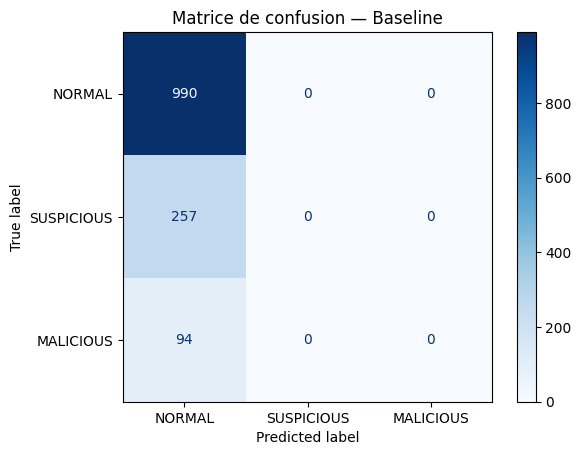

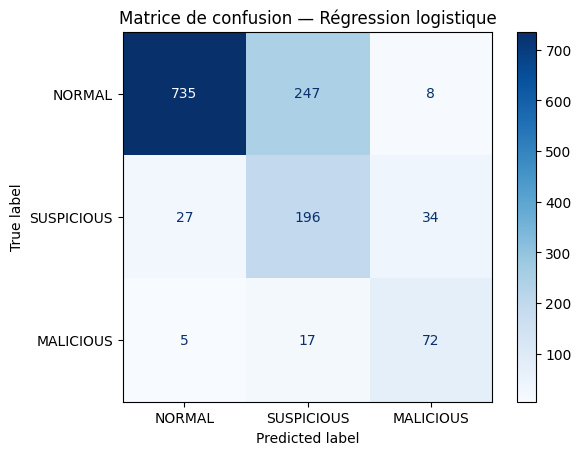

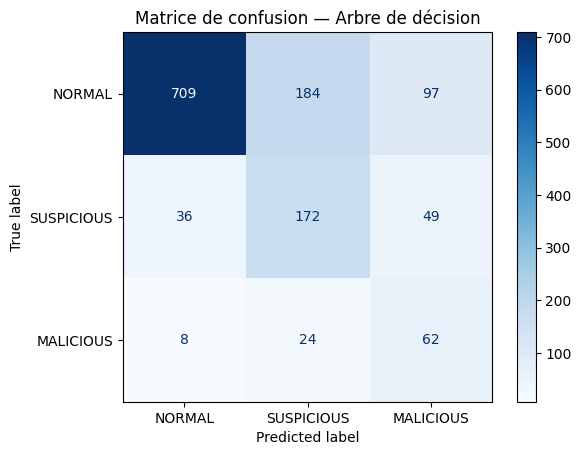

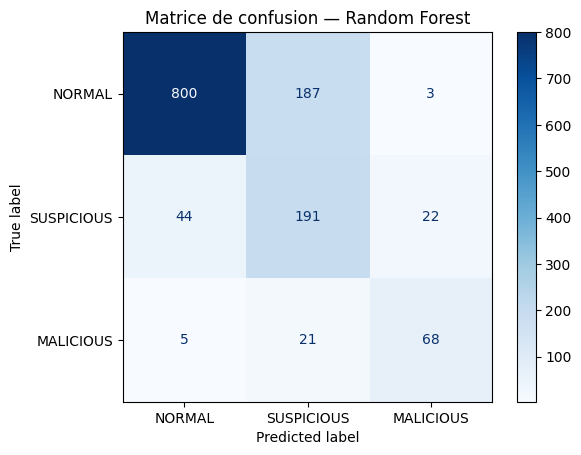

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay

for model_name, predictions in models_predictions.items():

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=labels,
        cmap="Blues"
    )

    plt.title(f"Matrice de confusion — {model_name}")
    plt.show()

### Analyse des résultats

La baseline atteint 73,8 % d'accuracy mais ne détecte aucun événement
`SUSPICIOUS` ou `MALICIOUS`. Elle confirme que l'accuracy seule est peu
pertinente sur ce dataset déséquilibré.

La forêt aléatoire obtient les meilleures performances globales avec environ
79 % d'accuracy et un macro F1 de 0,73.

La régression logistique obtient cependant le meilleur recall sur la classe
`MALICIOUS` avec environ 76,6 %, contre 72,3 % pour la forêt aléatoire.
Elle produit ainsi 22 faux négatifs, contre 26 pour la forêt aléatoire.

L'arbre de décision seul est moins performant : il génère notamment beaucoup
plus de faux positifs sur la classe `MALICIOUS`.

La forêt aléatoire est donc le meilleur modèle en performance globale, tandis
que la régression logistique est plus efficace pour limiter les événements
malveillants non détectés.

## 10. Analyse des erreurs et arbitrage métier

**Question centrale :** entre un faux positif et un faux négatif, lequel est le plus grave dans ce contexte ?

- Faux positif : un événement bénin est remonté aux analystes.
- Faux négatif : un événement malveillant n'est jamais investigué.

Quel compromis retenez-vous, et pourquoi ? Votre réponse doit être argumentée : il n'y a pas une seule bonne réponse, mais il y a des justifications solides et des justifications faibles.

In [54]:
# TODO : analyse des erreurs
# Comparaison détaillée des erreurs MALICIOUS

error_comparison = pd.DataFrame({
    "Modèle": [
        "Régression logistique",
        "Random Forest"
    ],
    "Faux positifs MALICIOUS": [
        ((y_test != "MALICIOUS") & (y_pred_logistic == "MALICIOUS")).sum(),
        ((y_test != "MALICIOUS") & (y_pred_forest == "MALICIOUS")).sum()
    ],
    "Faux négatifs MALICIOUS": [
        ((y_test == "MALICIOUS") & (y_pred_logistic != "MALICIOUS")).sum(),
        ((y_test == "MALICIOUS") & (y_pred_forest != "MALICIOUS")).sum()
    ]
})

print(error_comparison.to_string(index=False))

print("\nRégression logistique — MALICIOUS mal classés :")
print(
    pd.crosstab(
        y_test[y_test == "MALICIOUS"],
        y_pred_logistic[y_test == "MALICIOUS"],
        rownames=["Réel"],
        colnames=["Prédit"]
    )
)

print("\nRandom Forest — MALICIOUS mal classés :")
print(
    pd.crosstab(
        y_test[y_test == "MALICIOUS"],
        y_pred_forest[y_test == "MALICIOUS"],
        rownames=["Réel"],
        colnames=["Prédit"]
    )
)

               Modèle  Faux positifs MALICIOUS  Faux négatifs MALICIOUS
Régression logistique                       42                       22
        Random Forest                       25                       26

Régression logistique — MALICIOUS mal classés :
Prédit     MALICIOUS  NORMAL  SUSPICIOUS
Réel                                    
MALICIOUS         72       5          17

Random Forest — MALICIOUS mal classés :
Prédit     MALICIOUS  NORMAL  SUSPICIOUS
Réel                                    
MALICIOUS         68       5          21


### Arbitrage métier

Dans ce contexte, toutes les erreurs ne présentent pas le même niveau de risque.

Un événement `MALICIOUS` classé `NORMAL` représente l'erreur la plus critique,
car il risque de ne pas être investigué. À l'inverse, un événement `MALICIOUS`
classé `SUSPICIOUS` reste soumis à une vérification humaine.

La régression logistique produit 22 faux négatifs `MALICIOUS`, contre 26 pour
la forêt aléatoire. Cependant, les deux modèles classent seulement 5 événements
`MALICIOUS` comme `NORMAL`.

La différence provient donc des événements `MALICIOUS` classés `SUSPICIOUS` :
17 pour la régression logistique contre 21 pour la forêt aléatoire. Ces événements
restent néanmoins transmis aux analystes.

La forêt aléatoire présente par ailleurs de meilleures performances globales
et génère moins de faux positifs `MALICIOUS` (25 contre 42).

Elle offre donc ici un meilleur compromis entre détection des incidents et
charge de travail pour les analystes.

## 11. Choix du modèle final

Quel modèle recommandez-vous à la direction, et sur quels critères ?

Attention : le meilleur modèle statistique n'est pas nécessairement le meilleur choix opérationnel.

In [55]:
# TODO
final_model = forest_model

print("Modèle retenu : Random Forest")
print("Accuracy :", round(accuracy_score(y_test, y_pred_forest), 3))
print("Macro F1 :", round(f1_score(y_test, y_pred_forest, average="macro"), 3))

malicious_as_normal = (
    (y_test == "MALICIOUS")
    & (y_pred_forest == "NORMAL")
).sum()

print("MALICIOUS classés NORMAL :", malicious_as_normal)

Modèle retenu : Random Forest
Accuracy : 0.79
Macro F1 : 0.727
MALICIOUS classés NORMAL : 5


### Modèle final retenu

La **Random Forest** est retenue comme modèle final.

Elle obtient les meilleures performances globales avec environ **79 % d'accuracy**
et un **macro F1 de 0,73**.

Même si la régression logistique possède un recall légèrement supérieur sur
`MALICIOUS`, les deux modèles classent exactement 5 événements malveillants
comme `NORMAL`, ce qui constitue l'erreur opérationnelle la plus critique.

La Random Forest génère également moins de faux positifs `MALICIOUS`
(25 contre 42), ce qui limite la charge inutile pour les analystes.

Elle représente donc le meilleur compromis entre performance statistique,
détection des incidents critiques et charge opérationnelle.

## 12. Impact projet

Dernière étape, et pas la moins importante.

Au cours de la séance, le formateur vous remettra des **cartes événement** décrivant des changements survenant sur le projet. Pour chacune, mettez à jour :

- le backlog ;
- le planning ;
- le Risk Register ;
- l'architecture si nécessaire.

Documentez chaque décision : impact, criticité, responsable, arbitrage retenu.

### Carte 1 - Trop de faux positifs

**Événement :**  
35 % des alertes remontées comme suspectes sont finalement considérées comme
bénignes par les analystes. Cette charge supplémentaire devient difficilement
acceptable pour l'équipe sécurité.

**Décision :**  
Le prototype ne doit pas être déployé en l'état. Une nouvelle itération est
ajoutée afin de réduire le nombre de faux positifs sans dégrader fortement la
détection des événements réellement malveillants.

**Actions :**
- analyser les faux positifs pour identifier les catégories les plus fréquentes ;
- ajouter des règles de filtrage pour les alertes répétitives clairement bénignes ;
- ajuster les paramètres du modèle et éventuellement les seuils de décision ;
- tester à nouveau les performances après modification ;
- vérifier particulièrement que le nombre de `MALICIOUS` classés `NORMAL`
  n'augmente pas ;
- faire valider le nouveau compromis par les analystes sécurité.

#### Impact sur le backlog

Ajout d'une priorité haute :
**Réduire les faux positifs générés par le système de priorisation.**

Sous-tâches :
- analyser les faux positifs ;
- identifier les sources de bruit ;
- ajuster le modèle ou les règles de filtrage ;
- refaire l'évaluation ;
- validation par les analystes.

#### Impact sur le planning

Une itération supplémentaire est nécessaire avant la mise en production.

Le déploiement est donc reporté jusqu'à ce que le niveau de faux positifs soit
jugé acceptable par l'équipe sécurité.

#### Mise à jour du Risk Register

**Risque :** surcharge des analystes liée aux faux positifs.

**Probabilité :** élevée  
**Impact :** élevé

**Conséquences :**
- fatigue des analystes ;
- perte de confiance dans le système ;
- risque que certaines alertes importantes soient ignorées.

**Mesures :**
- suivi du taux de faux positifs ;
- analyse régulière des erreurs ;
- filtrage des alertes répétitives bénignes ;
- validation humaine avant mise en production.

In [57]:
# TODO : suivi des décisions prises suite aux cartes événement
# Création d'un jeu de validation à partir du train
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train
)

# On réentraîne la Random Forest uniquement sur X_fit
forest_adjusted = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

forest_adjusted.fit(X_fit, y_fit)

# Probabilités sur le jeu de validation
proba = forest_adjusted.predict_proba(X_val)

classes = forest_adjusted.named_steps["model"].classes_

malicious_index = list(classes).index("MALICIOUS")
suspicious_index = list(classes).index("SUSPICIOUS")

p_malicious = proba[:, malicious_index]
p_suspicious = proba[:, suspicious_index]

In [58]:
threshold_results = []

for suspicious_threshold in [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:

    predictions = []

    for p_mal, p_susp in zip(p_malicious, p_suspicious):

        # On reste volontairement sensible aux événements MALICIOUS
        if p_mal >= 0.40:
            predictions.append("MALICIOUS")

        # On devient plus exigeant pour SUSPICIOUS
        elif p_susp >= suspicious_threshold:
            predictions.append("SUSPICIOUS")

        else:
            predictions.append("NORMAL")

    predictions = np.array(predictions)

    # Événements prédits SUSPICIOUS
    suspicious_mask = predictions == "SUSPICIOUS"
    nb_suspicious = suspicious_mask.sum()

    # Parmi eux, combien étaient réellement NORMAL ?
    if nb_suspicious > 0:
        benign_rate = (
            (y_val.to_numpy()[suspicious_mask] == "NORMAL").sum()
            / nb_suspicious
        )
    else:
        benign_rate = 0

    # Erreur la plus dangereuse : MALICIOUS -> NORMAL
    malicious_as_normal = (
        (y_val.to_numpy() == "MALICIOUS")
        & (predictions == "NORMAL")
    ).sum()

    threshold_results.append({
        "Seuil SUSPICIOUS": suspicious_threshold,
        "Alertes SUSPICIOUS": nb_suspicious,
        "% bénignes parmi SUSPICIOUS": benign_rate * 100,
        "MALICIOUS -> NORMAL": malicious_as_normal
    })

threshold_df = pd.DataFrame(threshold_results)

print(
    threshold_df
    .round(2)
    .to_string(index=False)
)

 Seuil SUSPICIOUS  Alertes SUSPICIOUS  % bénignes parmi SUSPICIOUS  MALICIOUS -> NORMAL
             0.40                 351                        48.43                    7
             0.45                 312                        45.83                    9
             0.50                 250                        45.60                   14
             0.55                 143                        40.56                   21
             0.60                  57                        26.32                   23
             0.65                  21                        23.81                   25
             0.70                   3                        33.33                   27


### Analyse du premier ajustement des seuils

Le premier test consiste à augmenter uniquement le seuil utilisé pour classer
un événement comme `SUSPICIOUS`.

Les résultats montrent qu'en augmentant ce seuil, le pourcentage d'alertes
suspectes finalement bénignes diminue. Par exemple, avec un seuil de `0.60`,
ce taux descend à environ **26,3 %**, ce qui répond au problème de surcharge
signalé dans la carte événement.

Cependant, cette amélioration se fait au prix d'une forte augmentation des
événements `MALICIOUS` classés `NORMAL`. Avec ce même seuil de `0.60`,
on obtient **23 événements malveillants classés comme normaux**, contre seulement
7 avec un seuil de `0.40`.

Ce compromis n'est donc pas acceptable : réduire les faux positifs ne doit pas
conduire à laisser passer davantage d'incidents réellement malveillants.

Nous allons donc tester simultanément deux seuils :
- un seuil pour la classe `MALICIOUS` ;
- un seuil pour la classe `SUSPICIOUS`.

L'objectif est de réduire la proportion d'alertes `SUSPICIOUS` bénignes tout
en conservant un nombre faible de `MALICIOUS` classés `NORMAL`.

In [59]:
threshold_results = []

for malicious_threshold in [0.20, 0.25, 0.30, 0.35, 0.40]:

    for suspicious_threshold in [0.50, 0.55, 0.60, 0.65]:

        predictions = []

        for p_mal, p_susp in zip(p_malicious, p_suspicious):

            if p_mal >= malicious_threshold:
                predictions.append("MALICIOUS")

            elif p_susp >= suspicious_threshold:
                predictions.append("SUSPICIOUS")

            else:
                predictions.append("NORMAL")

        predictions = np.array(predictions)

        suspicious_mask = predictions == "SUSPICIOUS"
        nb_suspicious = suspicious_mask.sum()

        if nb_suspicious > 0:
            benign_rate = (
                (y_val.to_numpy()[suspicious_mask] == "NORMAL").sum()
                / nb_suspicious
            )
        else:
            benign_rate = 0

        malicious_as_normal = (
            (y_val.to_numpy() == "MALICIOUS")
            & (predictions == "NORMAL")
        ).sum()

        false_malicious = (
            (y_val.to_numpy() != "MALICIOUS")
            & (predictions == "MALICIOUS")
        ).sum()

        threshold_results.append({
            "Seuil MALICIOUS": malicious_threshold,
            "Seuil SUSPICIOUS": suspicious_threshold,
            "% bénignes SUSPICIOUS": benign_rate * 100,
            "MALICIOUS -> NORMAL": malicious_as_normal,
            "FP MALICIOUS": false_malicious
        })


threshold_grid = pd.DataFrame(threshold_results)

# On affiche en priorité les configurations sous 35 % de faux suspects
acceptable = threshold_grid[
    threshold_grid["% bénignes SUSPICIOUS"] <= 35
].sort_values(
    ["MALICIOUS -> NORMAL", "FP MALICIOUS"]
)

print(
    acceptable
    .round(2)
    .to_string(index=False)
)

 Seuil MALICIOUS  Seuil SUSPICIOUS  % bénignes SUSPICIOUS  MALICIOUS -> NORMAL  FP MALICIOUS
            0.20              0.60                  34.88                    9           169
            0.20              0.65                  29.41                   10           169
            0.25              0.60                  28.30                   12            87
            0.25              0.65                  25.00                   13            87
            0.30              0.60                  26.32                   15            44
            0.30              0.65                  23.81                   17            44
            0.35              0.60                  26.32                   18            32
            0.35              0.65                  23.81                   20            32
            0.40              0.60                  26.32                   23            26
            0.40              0.65                  23.81             